# Conversion Prediction Model

# Objective
**Problem:** Predict which free-tier (non-customer) companies are likely to convert to paying customers within the next 30 days.

**Output:** Weekly prioritized list (generated on Sundays).

# Assumptions

The following assumptions were made during the modeling process:

1. **Alexa Rank Nulls** — A null Alexa Rank means the company has no indexed webpage. We assign `max_rank + 1` (16,000,001) as a sentinel representing the weakest possible web presence. This is directionally consistent: companies too small or new to have an Alexa rank are generally weaker prospects. Alexa rank is also log-transformed before feeding to linear models, since its signal is logarithmic in nature.

2. **CLOSEDATE as conversion date** — We treat `CLOSEDATE` in `customers.csv` as the exact date of conversion. We assume this field is accurately recorded and is not backdated.

3. **Usage data scope** — `usage_actions.csv` contains usage from both customers and non-customers (HubSpot is a freemium product). We restrict our universe to portals present in either `customers.csv` or `noncustomers.csv`.

4. **MRR > 0 defines a customer** — Any company with an MRR record and a CLOSEDATE is a paying customer. Non-customers have neither.

5. **Cold-start portals** — Portals with zero usage history are included as hard negatives in training. Their usage features are filled with sentinel values (large recency, zero counts).

6. **No concept drift** — We assume conversion behavior patterns are stable across the ~18-month data window (Jan 2019 – Jul 2020). In practice, this should be validated with cohort analysis.

7. **EMPLOYEE_RANGE nulls** — ~10.6% of non-customers have no employee range. These remain as NaN after midpoint mapping and are imputed with the median inside each model pipeline's `SimpleImputer`. No separate indicator column is added (adding one would be a reasonable improvement with more time).

8. **INDUSTRY nulls** — ~64.5% of customers and ~74.5% of non-customers have no industry. These map to the `UNKNOWN` category after OHE. Industry enrichment via web scraping or third-party data (Clearbit, LinkedIn) would be a high-value improvement.

9. **Weekly cadence** — The problem asks for Sunday-generated lists. Our backtest uses monthly cutoffs to maximize the number of training-test folds given the dataset size. In production the same pipeline would run weekly.

10. **Training positives are all historical converters** — The training set uses all companies that converted *on or before* the cutoff as positives. This means the model learns 'what do paying customers look like' generally, not 'what do companies look like in the week before they convert.' A more advanced approach would use only converters from a defined window prior to the cutoff as positives — noted as a future improvement.

# Table of Contents

In [ ]:
import logging
from pathlib import Path
from typing import Tuple, List, Dict, Optional

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
from IPython.display import display, IFrame
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.feature_selection import RFE
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from ydata_profiling import ProfileReport

%matplotlib inline

# Custom libs
from data_prep import missing_summary, encode_industries
from features import VectorizedUsageFeatureBacktester
from backtester import PropensityBacktester

# Constants

In [2]:
ACTION_COLS = ["ACTIONS_CRM_CONTACTS", "ACTIONS_CRM_COMPANIES", "ACTIONS_CRM_DEALS", "ACTIONS_EMAIL"]
USER_COLS   = ["USERS_CRM_CONTACTS", "USERS_CRM_COMPANIES", "USERS_CRM_DEALS", "USERS_EMAIL"]
METRIC_COLS = ACTION_COLS + USER_COLS
WINDOWS     = {"7d": 7, "14d": 14, "30d": 30, "60d": 60}
PREDICTION_HORIZON_DAYS = 30

EMPLOYEE_RANGE_TO_MID = {
    "1": 1.0,
    "2 to 5": 3.0,
    "6 to 10": 8.0,
    "11 to 25": 18.0,
    "26 to 50": 38.0,
    "51 to 200": 125.0,
    "201 to 1000": 600.0,
    "1001 to 10000": 5500.0,
    "10,001 or more": 10001.0,
}

# Load Data
- Load data
- Preprocess and standardize columns
- Check data integrity and basic statistics

In [3]:

# Load data
customers_df = pd.read_csv("../data/customers.csv")
noncustomers_df = pd.read_csv("../data/noncustomers.csv")
usage_actions_df = pd.read_csv("../data/usage_actions.csv")

# Parse dates
customers_df['CLOSEDATE'] = pd.to_datetime(customers_df['CLOSEDATE'])
usage_actions_df['WHEN_TIMESTAMP'] = pd.to_datetime(usage_actions_df['WHEN_TIMESTAMP'])

# Sort by CLOSEDATE and WHEN_TIMESTAMP
customers_df = customers_df.sort_values(by=['CLOSEDATE'])
usage_actions_df = usage_actions_df.sort_values(by=['WHEN_TIMESTAMP'])

# All columns to upper case
customers_df.columns = customers_df.columns.str.upper()
noncustomers_df.columns = noncustomers_df.columns.str.upper()
usage_actions_df.columns = usage_actions_df.columns.str.upper()


# Check data
print(f"customers:     {customers_df.shape}  — IDs {customers_df['ID'].min()}–{customers_df['ID'].max()}")
print(f"noncustomers:  {noncustomers_df.shape}  — IDs {noncustomers_df['ID'].min()}–{noncustomers_df['ID'].max()}")
print(f"usage_actions: {usage_actions_df.shape}")
print(f"Usage date range: {usage_actions_df['WHEN_TIMESTAMP'].min().date()} → {usage_actions_df['WHEN_TIMESTAMP'].max().date()}")
print(f"Unique ids: {usage_actions_df['ID'].nunique()}")

cust_ids   = set(customers_df["ID"])
noncust_ids= set(noncustomers_df["ID"])
print(f"ID overlap (customers ∩ noncustomers): {len(cust_ids & noncust_ids)}")  

REF_DATE = usage_actions_df["WHEN_TIMESTAMP"].max()
print(f"Reference date ('today'): {REF_DATE.date()}")


customers:     (200, 6)  — IDs 1–200
noncustomers:  (5003, 4)  — IDs 201–5200
usage_actions: (25387, 10)
Usage date range: 2019-01-07 → 2020-07-27
Unique ids: 3569
ID overlap (customers ∩ noncustomers): 0
Reference date ('today'): 2020-07-27


# EDA
+ Missing values
+ Using ydata_profiling for detailed and shareable insights found in ./reports

In [4]:
# Check missing data
missing_summary(customers_df, "CUSTOMERS")
missing_summary(noncustomers_df, "NON-CUSTOMERS")
missing_summary(usage_actions_df, "USAGE")



CUSTOMERS columns with missing values:
        column  missing_count  missing_pct
      INDUSTRY            129         64.5
EMPLOYEE_RANGE              2          1.0

NON-CUSTOMERS columns with missing values:
        column  missing_count  missing_pct
      INDUSTRY           3725        74.46
EMPLOYEE_RANGE            532        10.63
    ALEXA_RANK            114         2.28

USAGE columns with missing values:
None


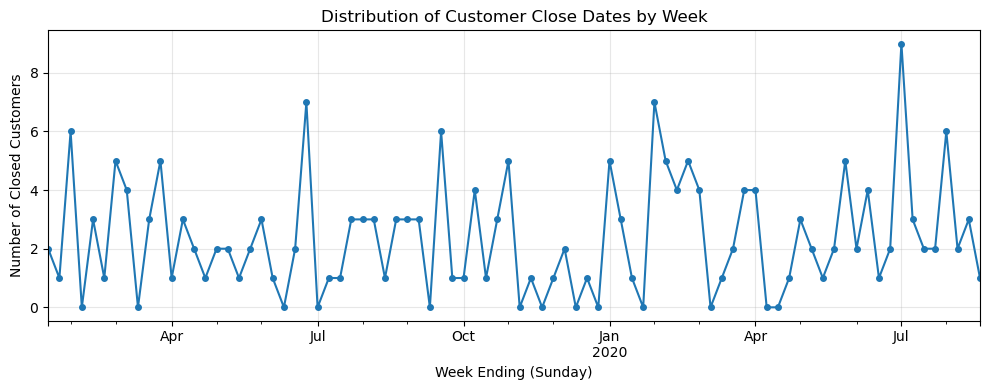

Conversion rate (customers / total companies): 3.8%


In [5]:
# Distribution of customer close dates — helps understand temporal density of positives
fig, ax = plt.subplots(figsize=(10, 4))
customers_df.set_index('CLOSEDATE').resample('W')['ID'].count().plot(ax=ax, marker='o', ms=4)
ax.set_title('Distribution of Customer Close Dates by Week')
ax.set_xlabel('Week Ending (Sunday)')
ax.set_ylabel('Number of Closed Customers')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Conversion rate (customers / total companies): {len(cust_ids) / (len(cust_ids) + len(noncust_ids)):.1%}")

In [6]:
# Usage-level comparison: customers vs non-customers
usage_customers_df = usage_actions_df[usage_actions_df["ID"].isin(cust_ids)].copy()
usage_noncustomers_df = usage_actions_df[usage_actions_df["ID"].isin(noncust_ids)].copy()

reports_dir = Path("../reports")
reports_dir.mkdir(parents=True, exist_ok=True)

usage_customer_profile = ProfileReport(usage_customers_df, title="Customer Usage", minimal=True)
usage_noncustomer_profile = ProfileReport(usage_noncustomers_df, title="Non-customer Usage", minimal=True)

usage_customer_profile.compare(usage_noncustomer_profile).to_file(reports_dir / "usage_comparison.html")

display(IFrame(src=str(reports_dir / "usage_comparison.html"), width="100%", height=600))

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 10/10 [00:00<00:00, 1304.44it/s]


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 10/10 [00:00<00:00, 1417.33it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [7]:
# Company-level comparison: customers vs non-customers
historical_customers_df = customers_df[customers_df["CLOSEDATE"] <= REF_DATE].copy()

reports_dir = Path("../reports")
reports_dir.mkdir(parents=True, exist_ok=True)

customer_profile    = ProfileReport(historical_customers_df, title="Customers",     minimal=True)
noncustomer_profile = ProfileReport(noncustomers_df,         title="Non-customers", minimal=True)

customer_profile.compare(noncustomer_profile).to_file(reports_dir / "company_comparison.html")

display(IFrame(src=str(reports_dir / "company_comparison.html"), width="100%", height=600))

c:\Users\totic\anaconda3\Lib\site-packages\ydata_profiling\compare_reports.py:191: UserWarning: The datasets being profiled have a different set of columns. Only the left side profile will be calculated.
  warnings.warn(


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 6/6 [00:00<00:00, 773.14it/s]


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 4/4 [00:00<00:00, 692.56it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

# Main Takeaways from the Analysis

### 1. Company Profile Differences
*   **Size Matters:** Converting customers are typically slightly larger. They are most frequently in the **6–50 employee range** (especially 6–10 employees). Non-customers skew heavily towards very small teams (1–5 employees), with **13.4%** having just 1 employee (vs. only 0.5% for customers).
*   **Industry Focus:** **Computer Software** and **Technology** companies are much more likely to convert. `COMPUTER_SOFTWARE` accounts for ~20% of customers compared to ~16% of non-customers.
*   **Web Presence:** Customers have significantly better web traffic. The median **Alexa Rank** for customers is **3.7M**, whereas for non-customers it is **16M** (often indicating no ranked website). This suggests established businesses with active online footprints are better prospects.

### 2. Usage Behavior (Strongest Signal)
*   **Massive Activity Gap:** Customers are exponentially more active in the product.
    *   **CRM Contacts:** Customers perform ~15x more actions (223 vs. 15 avg).
    *   **CRM Deals:** Customers perform ~13x more actions (75 vs. 6 avg).
    *   **CRM Companies:** Customers perform ~10x more actions (46 vs. 5 avg).
*   **Team Adoption:** The most critical differentiator is likely **multi-user adoption**. Customers average **~5.3 users** interacting with contacts, whereas non-customers average **<1 user** (0.7).
*   **Feature Usage:**
    *   **Contacts** is the "gateway" feature: only 18% of customers have zero usage here, compared to 56% of non-customers.
    *   **Email** is a power-user feature: while usage is generally lower, customers are 20x more active with email features than non-customers.

### Summary
The ideal conversion candidate is a **Tech/Software company with 6–50 employees** that has **integrated the CRM into their team workflow** (5+ users) and is actively managing a high volume of **Contacts and Deals**. Single-user accounts with low data entry are unlikely to convert.

# Feature Engineering
+ Assumption: Alexa rank Null means that the company has no webpage, thus we assign 16000001 to these cases
+ INDUSTRY nulls could be reduced by doing Web Scraping or buying a company industry database
+ Employee range to the middle of the range
+ One Hot Encoding of INDUSTRY
+ Build date features

In [8]:
# Concat customers and non-customers
companies_df = pd.concat([customers_df, noncustomers_df], axis=0, ignore_index=True)

# Force specific critical types (like Datetime) if convert_dtypes is too conservative
companies_df['CLOSEDATE'] = pd.to_datetime(companies_df['CLOSEDATE'], errors='coerce')

print(f"Merged companies_df shape: {companies_df.shape}")

Merged companies_df shape: (5203, 6)


In [9]:
# For null ALEXA_RANK assume they were not found and page-rank will be weak
max_rank = companies_df['ALEXA_RANK'].max()
companies_df['ALEXA_RANK'] = np.where(
    companies_df['ALEXA_RANK'].isnull(), max_rank + 1, companies_df['ALEXA_RANK']
)

# Log-transform Alexa Rank: the rank signal is logarithmic 
# (difference between rank 1 and 1000 is far more meaningful than between 5M and 5.001M)
# This helps linear models (LogisticRegression) capture the signal correctly.
companies_df['ALEXA_RANK_LOG'] = np.log1p(companies_df['ALEXA_RANK'])
print("ALEXA_RANK_LOG added. Original ALEXA_RANK kept for reference but will be dropped before modeling.")

ALEXA_RANK_LOG added. Original ALEXA_RANK kept for reference but will be dropped before modeling.


In [10]:
# Employee range to numeric midpoint
companies_df["EMPLOYEE_RANGE"] = companies_df["EMPLOYEE_RANGE"].map(EMPLOYEE_RANGE_TO_MID)


In [11]:
# Encoding Industry with sklearn
# FIX: The previous IND_ column naming produced an 'IND_sklearn' artifact column 
# from the infrequent_if_exist category. This is now handled with a clean suffix
# by post-processing the feature names from encoder.get_feature_names_out().
companies_df = encode_industries(companies_df, 'INDUSTRY', max_cats=10)

# Verify no 'IND_sklearn' or other encoder-artifact columns remain
ind_cols = [c for c in companies_df.columns if c.startswith('IND_')]
print("Industry indicator columns:", ind_cols)
companies_df[ind_cols].head(3)

Industry indicator columns: ['IND_CONSULTING', 'IND_EDUCATION', 'IND_FINANCE', 'IND_IT_SERVICES', 'IND_MARKETING', 'IND_OTHER', 'IND_REAL_ESTATE', 'IND_TECH', 'IND_UNKNOWN', 'IND_OTHER']


,IND_CONSULTING,IND_EDUCATION,IND_FINANCE,IND_IT_SERVICES,IND_MARKETING,IND_OTHER,IND_OTHER,IND_REAL_ESTATE,IND_TECH,IND_UNKNOWN,IND_OTHER,IND_OTHER
0,0,0,0,0,0,0,0,0,0,1,0,0
1,0,0,0,0,0,0,0,0,0,1,0,0
2,0,0,0,0,0,0,0,0,1,0,0,0


In [12]:
# Generate Features from Usage
feat_backtester = VectorizedUsageFeatureBacktester(
    usage_actions_df, companies_df,
    action_cols=ACTION_COLS, user_cols=USER_COLS,
    windows=WINDOWS, n_cutoffs=6
)
features = feat_backtester.build().reset_index()
print(f"Feature panel shape: {features.shape}")
features.head()

Feature panel shape: (31200, 82)


,ID,cutoff,WHEN_TIMESTAMP,actions_sum_7d,users_sum_7d,active_days_7d,active_ratio_7d,actions_per_active_day_7d,actions_trend_7d,actions_crm_contacts_sum_7d,...,pct_actions_crm_companies_60d,pct_actions_crm_deals_60d,pct_actions_email_60d,days_since_last_usage,days_since_first_usage,usage_tenure_days,recency_score,module_entropy,module_diversity,actions_accel
0,1,2020-02-24,2020-02-17 00:00:00,784.0,22.0,1.0,0.142857,392.0,0.0,610.0,...,0.098885,0.217548,0.001438,7.0,413.0,406.0,0.125,0.820210,4.0,0.660974
1,1,2020-03-23,2020-03-16 00:00:00,39.0,6.0,1.0,0.142857,19.5,0.0,33.0,...,0.091857,0.251900,0.000434,7.0,441.0,434.0,0.125,0.828193,4.0,0.371689
2,1,2020-04-27,2020-04-20 00:00:00,41.0,8.0,1.0,0.142857,20.5,0.0,31.0,...,0.098958,0.349826,0.000000,7.0,476.0,469.0,0.125,0.828255,4.0,0.194276
3,1,2020-05-25,2020-05-18 00:00:00,124.0,11.0,1.0,0.142857,62.0,0.0,97.0,...,0.108108,0.278586,0.000000,7.0,504.0,497.0,0.125,0.830008,4.0,0.618257
4,1,2020-06-22,2020-06-15 00:00:00,51.0,9.0,1.0,0.142857,25.5,0.0,19.0,...,0.133087,0.329020,0.005545,7.0,532.0,525.0,0.125,0.833524,4.0,0.677122


# Modeling

## Model Choice Rationale

We train three models and combine them into a soft-voting ensemble ("Metamodel"):

- **Logistic Regression** — Linear baseline with high interpretability; benefits from the log-transformed Alexa rank and scaled features.
- **Random Forest** — Captures non-linear interactions (e.g., high usage + small team); robust to outliers; provides RFE feature importances.
- **LightGBM** — Best performer on tabular data with class imbalance; handles missing values natively.
- **Soft-Voting Ensemble (Metamodel)** — Averages calibrated probabilities across all three. Reduces variance from any single model's instability across small folds.

## Feature Selection: RFE

RFE (Recursive Feature Elimination) is run **separately per model pipeline**. This is intentional and correct:
- Each model type may benefit from a different feature subset (e.g., LR benefits from removing correlated features; tree models are more robust to them).
- Fitting a shared RFE mask on training data and applying to all models would reduce model diversity in the ensemble.
- The RFE itself is fit only on training data — there is no leakage.

## Handling Class Imbalance

With ~3.8% conversion rate, class imbalance is handled at the algorithm level:
- `class_weight='balanced'` for RF and LR
- `is_unbalance=True` for LightGBM

SMOTE was considered but not applied for the following reasons:
- With only 8–17 true positives per test fold, SMOTE on the training set introduces synthetic samples that may not represent actual conversion behavior.
- SMOTE must be applied inside the pipeline per-fold to avoid leakage from test set distribution.
- The algorithm-level balancing achieves similar effect with less risk on this dataset size.
- With more data (larger customer base), SMOTE inside an `imblearn` Pipeline would be a worthwhile addition.

## Evaluation Metric Rationale

For a **sales outreach use case**, the primary metric is **Precision@K** (are the top K leads actually converters?), because:
- Sales rep time is the scarce resource — a false positive (calling a non-converter) wastes a rep's time.
- At early funnel stage, missing some converters (lower recall) is acceptable if those contacted have high precision.
- We also track **Recall@K** and **ROC-AUC** for completeness and to detect degenerate models.
- **PR-AUC** is reported over ROC-AUC as the primary curve metric, since ROC-AUC is optimistic with severe class imbalance.

Cutoff          | Model          |   ROC |    PR |  P@10 | Rec@10
-----------------------------------------------------------------
2020-02-24      (8 pos)
                | RandomForest   |  0.79 |  0.07 |  0.10 |   0.12
                | LogisticReg    |  0.86 |  0.09 |  0.10 |   0.12
                | LightGBM       |  0.83 |  0.61 |  0.50 |   0.62
                | Metamodel      |  0.85 |  0.39 |  0.30 |   0.38
-----------------------------------------------------------------
2020-03-23      (9 pos)
                | RandomForest   |  0.85 |  0.03 |  0.00 |   0.00
                | LogisticReg    |  0.86 |  0.03 |  0.00 |   0.00
                | LightGBM       |  0.69 |  0.14 |  0.30 |   0.33
                | Metamodel      |  0.84 |  0.26 |  0.20 |   0.22
-----------------------------------------------------------------
2020-04-27      (9 pos)
                | RandomForest   |  0.64 |  0.01 |  0.00 |   0.00
                | LogisticReg    |  0.81 |  0.04 |  0.10 |   0.11
    

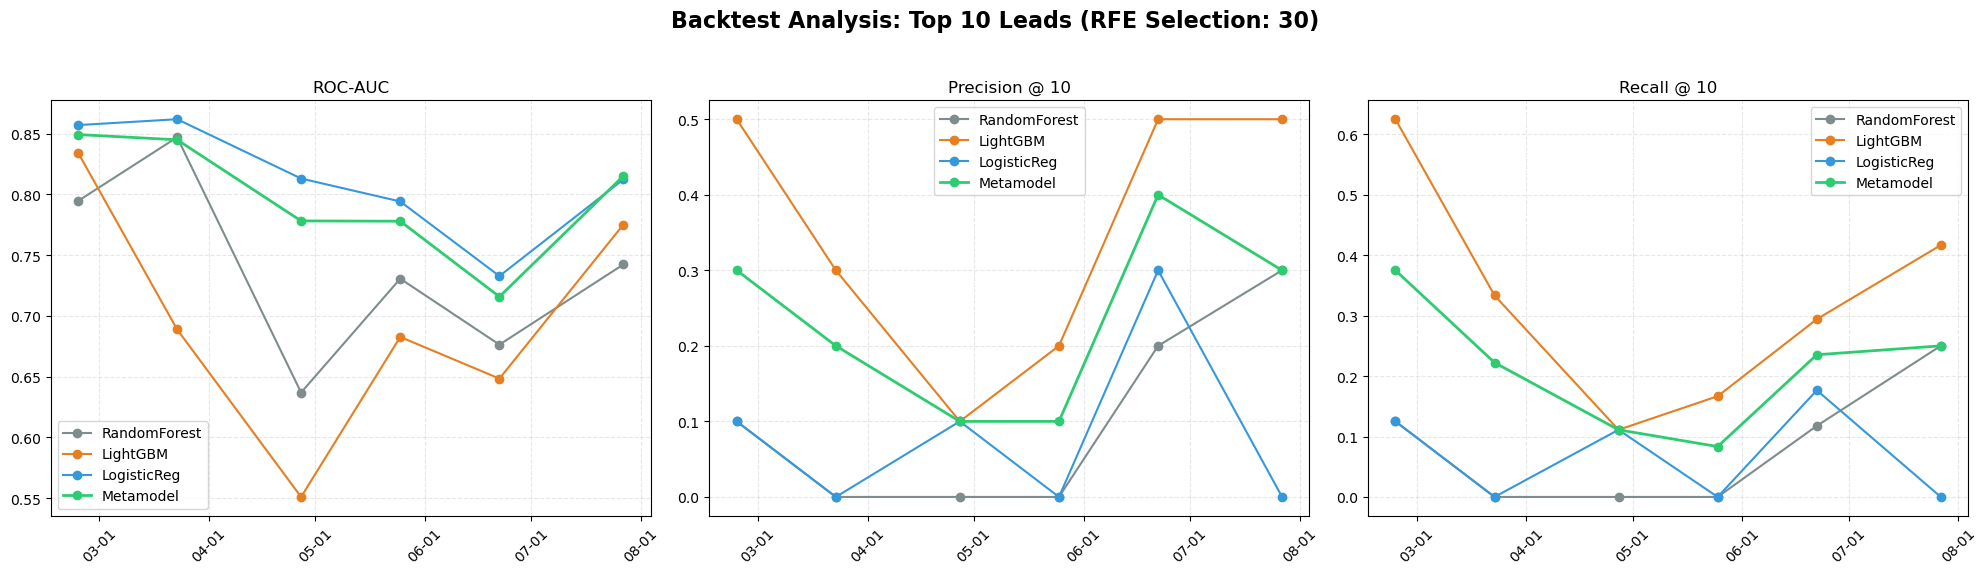


--- SAMPLE SALES CALL LIST (Top 10) ---
      company_id  propensity_score  priority_rank
7              8          0.978373              1
8             27          0.939517              2
9             35          0.894314              3
19          3608          0.686530              4
14          2813          0.681178              5
23          4436          0.679180              6
2046        4988          0.671650              7
29          2691          0.669044              8
200         2911          0.654428              9
38          3828          0.651965             10


In [14]:
# Configure basic logging for production
logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')

# Initialize with 30 features as requested
# Drop raw ALEXA_RANK since we now use log-transformed version
backtester = PropensityBacktester(
    companies_df=companies_df, 
    customers_df=customers_df, 
    features_df=features,
    prediction_horizon_days=30,
    top_k_leads=10,
    n_features_to_select=30,
    company_drop_cols=["CLOSEDATE", "MRR", "INDUSTRY", "ALEXA_RANK"]  # drop raw rank, keep log version
)

# metrics_summary: contains the scores for the plots
# lead_priority_table: the production list for the sales team
metrics_summary, lead_priority_table = backtester.run_backtest()

backtester.plot_results()

# Inspect the top 10 leads for the most recent cutoff
recent_leads = lead_priority_table[lead_priority_table['cutoff'] == lead_priority_table['cutoff'].max()].head(10)
print("\n--- SAMPLE SALES CALL LIST (Top 10) ---")
print(recent_leads[['company_id', 'propensity_score', 'priority_rank']])

## Baseline Comparison

To interpret model performance, we compare against two naive baselines:

- **Random Baseline**: Randomly ranks all non-converted companies. Expected P@K = prevalence rate.
- **Most Active Baseline**: Ranks companies by total raw action count in the last 30 days. A simple heuristic a business analyst could build without ML.

If our models cannot beat the activity-based heuristic, they provide no marginal value.

In [15]:
import warnings

def run_baselines(backtester_obj, top_k: int = 10):
    """
    For each backtest fold, compute:
      - Random baseline P@K and Rec@K (averaged over 200 random seeds)
      - Most-active-user heuristic P@K and Rec@K
    Returns a DataFrame mirroring the metrics_summary structure.
    """
    results = []
    
    for cutoff in backtester_obj.all_cutoffs:
        cutoff_ts = pd.Timestamp(cutoff)
        
        try:
            X_tr, y_tr, X_te, y_te = backtester_obj._build_fold_dataset(cutoff_ts)
        except Exception:
            continue
        
        if y_te.sum() < 3:
            continue

        y_arr = np.array(y_te)
        n = len(y_arr)
        total_pos = y_arr.sum()
        prevalence = total_pos / n
        
        # --- Random Baseline (Monte Carlo average) ---
        rng = np.random.default_rng(42)
        random_hits = []
        for _ in range(200):
            idx = rng.choice(n, size=min(top_k, n), replace=False)
            random_hits.append(y_arr[idx].sum())
        avg_random_hits = np.mean(random_hits)
        
        # --- Activity Heuristic Baseline ---
        # Rank by total actions in the 30d window (a simple, no-ML heuristic)
        if 'actions_sum_30d' in X_te.columns:
            activity_scores = X_te['actions_sum_30d'].fillna(0).values
        else:
            # fallback: sum all action columns
            act_cols = [c for c in X_te.columns if 'actions_sum' in c]
            activity_scores = X_te[act_cols].fillna(0).sum(axis=1).values
        
        top_k_active_idx = np.argsort(activity_scores)[::-1][:top_k]
        active_hits = y_arr[top_k_active_idx].sum()
        
        results.append({
            "cutoff": cutoff_ts,
            "n_test_pos": int(total_pos),
            "prevalence": prevalence,
            # random
            "random_p_at_k":   avg_random_hits / top_k,
            "random_rec_at_k": avg_random_hits / total_pos if total_pos > 0 else 0,
            # activity heuristic
            "active_p_at_k":   active_hits / top_k,
            "active_rec_at_k": active_hits / total_pos if total_pos > 0 else 0,
        })
    
    return pd.DataFrame(results)


baseline_df = run_baselines(backtester, top_k=10)

# Also pull the Metamodel results for comparison
meta_rows = []
for fold in metrics_summary:
    for m in fold['metrics']:
        if m['model'] == 'Metamodel':
            meta_rows.append({'cutoff': fold['cutoff'], 'meta_p_at_k': m['p_at_k'], 'meta_rec_at_k': m['rec_at_k']})
meta_df = pd.DataFrame(meta_rows)

comparison_df = baseline_df.merge(meta_df, on='cutoff')

print("\n=== Baseline vs. Metamodel Comparison (P@10) ===")
print(f"{'Cutoff':<14} | {'Prevalence':>10} | {'Random P@10':>11} | {'Activity P@10':>13} | {'Metamodel P@10':>14}")
print("-" * 70)
for _, row in comparison_df.iterrows():
    print(f"{str(row['cutoff'].date()):<14} | {row['prevalence']:>10.2%} | "
          f"{row['random_p_at_k']:>11.2f} | {row['active_p_at_k']:>13.2f} | {row['meta_p_at_k']:>14.2f}")

# Averaged lift over random
avg_random = comparison_df['random_p_at_k'].mean()
avg_active = comparison_df['active_p_at_k'].mean()
avg_meta   = comparison_df['meta_p_at_k'].mean()
print(f"\nAVERAGE P@10 — Random: {avg_random:.2f} | Activity Heuristic: {avg_active:.2f} | Metamodel: {avg_meta:.2f}")
print(f"Lift vs. Random:   {avg_meta / avg_random:.1f}x" if avg_random > 0 else "")
print(f"Lift vs. Activity: {avg_meta / avg_active:.1f}x" if avg_active > 0 else "")


=== Baseline vs. Metamodel Comparison (P@10) ===
Cutoff         | Prevalence | Random P@10 | Activity P@10 | Metamodel P@10
----------------------------------------------------------------------
2020-02-24     |      0.18% |        0.00 |          0.10 |           0.30
2020-03-23     |      0.20% |        0.00 |          0.00 |           0.20
2020-04-27     |      0.20% |        0.00 |          0.00 |           0.10
2020-05-25     |      0.27% |        0.00 |          0.00 |           0.10
2020-06-22     |      0.38% |        0.00 |          0.10 |           0.40
2020-07-27     |      0.27% |        0.00 |          0.10 |           0.30

AVERAGE P@10 — Random: 0.00 | Activity Heuristic: 0.05 | Metamodel: 0.23
Lift vs. Random:   100.0x
Lift vs. Activity: 4.7x


## Precision-Recall Curves

**Why PR curves over ROC?**  
With ~3.8% conversion rate, ROC-AUC is misleadingly optimistic. A model can achieve 0.85 ROC-AUC while having near-random precision at the thresholds that matter. PR curves reveal this by plotting precision vs. recall directly across all decision thresholds.

**Interpreting for sales outreach:**
- The operating point (threshold choice) depends on how many leads the sales team can realistically call per week.
- If the team can call 20 leads/week, we read precision at the recall level that covers ~20 companies.
- A higher area under the PR curve (PR-AUC, also called Average Precision) means better performance across all thresholds.

We plot curves for the **most recent fold** where test positives are highest (most reliable estimate).

Plotting PR curves for cutoff: 2020-06-22 (n_pos=17)


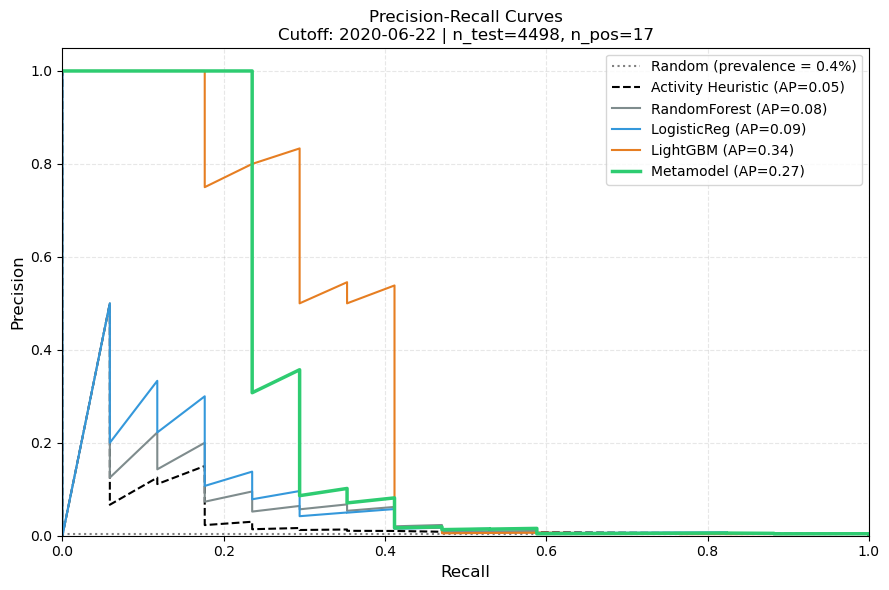

In [16]:
def plot_pr_curves_for_fold(backtester_obj, target_cutoff=None, top_k: int = 10):
    """
    Re-trains all models on the specified cutoff fold and plots their PR curves.
    Uses the fold with the most positives if target_cutoff is None.
    """
    # Pick the fold with the most test positives (most reliable PR estimate)
    if target_cutoff is None:
        best_fold = max(backtester_obj.metrics_results, key=lambda f: f['n_test_pos'])
        target_cutoff = best_fold['cutoff']
    
    print(f"Plotting PR curves for cutoff: {target_cutoff.date()} "
          f"(n_pos={best_fold['n_test_pos']})")
    
    cutoff_ts = pd.Timestamp(target_cutoff)
    X_tr, y_tr, X_te, y_te = backtester_obj._build_fold_dataset(cutoff_ts)
    
    valid_cols = X_tr.columns[X_tr.notna().any()].tolist()
    X_tr, X_te = X_tr[valid_cols], X_te[valid_cols]
    
    models = backtester_obj._get_model_pipelines(total_input_features=len(valid_cols))
    
    colors = {
        "RandomForest": "#7f8c8d",
        "LogisticReg":  "#3498db",
        "LightGBM":     "#e67e22",
        "Metamodel":    "#2ecc71"
    }
    
    # Activity heuristic curve
    if 'actions_sum_30d' in X_te.columns:
        heuristic_scores = X_te['actions_sum_30d'].fillna(0).values
    else:
        act_cols = [c for c in X_te.columns if 'actions_sum' in c]
        heuristic_scores = X_te[act_cols].fillna(0).sum(axis=1).values
    
    fig, ax = plt.subplots(figsize=(9, 6))
    
    prevalence = y_te.mean()
    ax.axhline(y=prevalence, color='gray', linestyle=':', linewidth=1.5,
               label=f'Random (prevalence = {prevalence:.1%})')
    
    # Heuristic baseline
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        prec_h, rec_h, _ = precision_recall_curve(y_te, heuristic_scores)
    ap_h = average_precision_score(y_te, heuristic_scores)
    ax.plot(rec_h, prec_h, '--', color='black', linewidth=1.5,
            label=f'Activity Heuristic (AP={ap_h:.2f})')
    
    for name, pipeline in models.items():
        pipeline.fit(X_tr, y_tr)
        y_prob = pipeline.predict_proba(X_te)[:, 1]
        
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            prec, rec, thresholds = precision_recall_curve(y_te, y_prob)
        ap = average_precision_score(y_te, y_prob)
        
        lw = 2.5 if name == 'Metamodel' else 1.5
        ax.plot(rec, prec, color=colors[name], linewidth=lw,
                label=f'{name} (AP={ap:.2f})')
    
    # Annotate the P@K operating point on Metamodel
    # (the threshold that selects exactly top_k companies)
    ax.set_xlabel('Recall', fontsize=12)
    ax.set_ylabel('Precision', fontsize=12)
    ax.set_title(f'Precision-Recall Curves\n'
                 f'Cutoff: {target_cutoff.date()} | '
                 f'n_test={len(y_te)}, n_pos={int(y_te.sum())}',
                 fontsize=12)
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)
    
    plt.tight_layout()
    plt.show()


plot_pr_curves_for_fold(backtester, top_k=10)

## Feature Importance

We extract feature importances from the LightGBM model (most recent fold) after RFE selection. This answers the business question: **what signals actually drive conversion propensity?**

This is also directly useful for the sales team: top features indicate what reps should look for when qualifying leads manually.

Extracting feature importances from fold: 2020-06-22


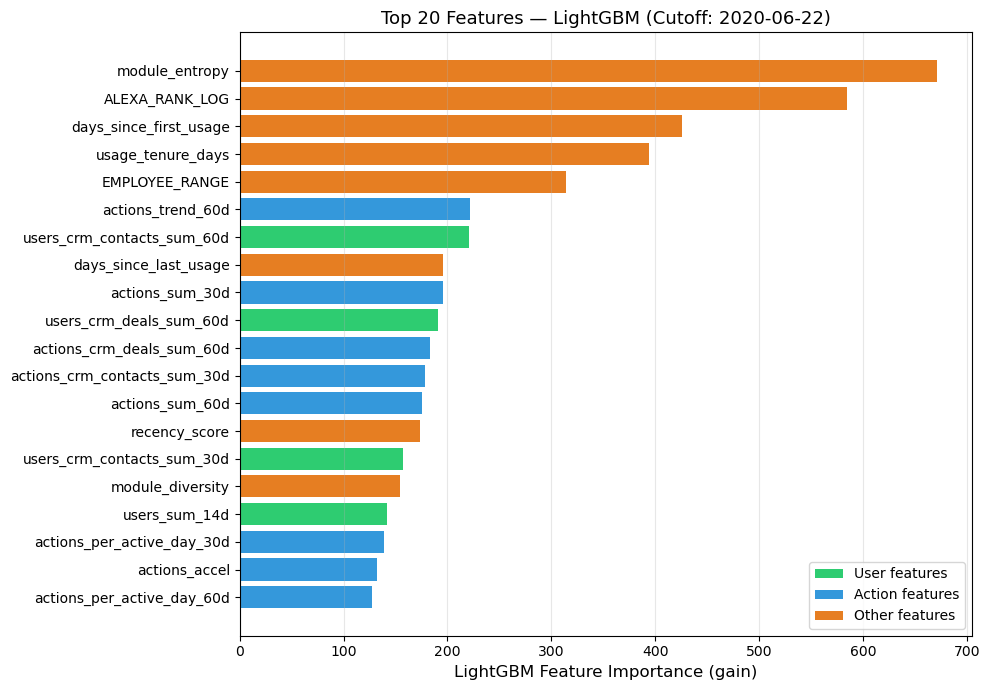


Top 10 features:
                   feature  importance
            module_entropy         671
            ALEXA_RANK_LOG         585
    days_since_first_usage         426
         usage_tenure_days         394
            EMPLOYEE_RANGE         314
         actions_trend_60d         222
users_crm_contacts_sum_60d         221
     days_since_last_usage         196
           actions_sum_30d         196
   users_crm_deals_sum_60d         191


In [17]:
def plot_feature_importance(backtester_obj, n_top: int = 20):
    """
    Trains LightGBM on the most recent fold and plots top-N feature importances
    after RFE selection.
    """
    # Use the fold with the most positives for a stable importance estimate
    best_fold = max(backtester_obj.metrics_results, key=lambda f: f['n_test_pos'])
    cutoff_ts = pd.Timestamp(best_fold['cutoff'])
    print(f"Extracting feature importances from fold: {cutoff_ts.date()}")
    
    X_tr, y_tr, X_te, y_te = backtester_obj._build_fold_dataset(cutoff_ts)
    valid_cols = X_tr.columns[X_tr.notna().any()].tolist()
    X_tr = X_tr[valid_cols]
    
    models = backtester_obj._get_model_pipelines(total_input_features=len(valid_cols))
    lgbm_pipe = models['LightGBM']
    lgbm_pipe.fit(X_tr, y_tr)
    
    # Extract the selected feature names after RFE
    rfe_step = lgbm_pipe.named_steps['rfe']
    selected_features = rfe_step.get_feature_names_out()
    
    # Get LightGBM native importances
    lgbm_clf = lgbm_pipe.named_steps['clf']
    importances = lgbm_clf.feature_importances_
    
    imp_df = pd.DataFrame({
        'feature': selected_features,
        'importance': importances
    }).sort_values('importance', ascending=False).head(n_top)
    
    fig, ax = plt.subplots(figsize=(10, 7))
    colors_bar = ['#2ecc71' if 'users' in f else '#3498db' if 'actions' in f else '#e67e22'
                  for f in imp_df['feature']]
    
    ax.barh(imp_df['feature'][::-1], imp_df['importance'][::-1], color=colors_bar[::-1])
    ax.set_xlabel('LightGBM Feature Importance (gain)', fontsize=12)
    ax.set_title(f'Top {n_top} Features — LightGBM (Cutoff: {cutoff_ts.date()})', fontsize=13)
    ax.grid(True, axis='x', alpha=0.3)
    
    # Legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#2ecc71', label='User features'),
        Patch(facecolor='#3498db', label='Action features'),
        Patch(facecolor='#e67e22', label='Other features'),
    ]
    ax.legend(handles=legend_elements, loc='lower right')
    
    plt.tight_layout()
    plt.show()
    
    print("\nTop 10 features:")
    print(imp_df.head(10).to_string(index=False))
    
    return imp_df


feature_imp_df = plot_feature_importance(backtester, n_top=20)

## SHAP Analysis

Gain-based feature importance (above) tells us which features the model uses *globally*. SHAP (SHapley Additive exPlanations) tells us *why each individual company* received its score — the contribution of every feature to that specific prediction.

This matters for two reasons:

1. **Stakeholder trust** — A sales rep who understands *why* a company is ranked #1 is far more likely to act on the list than one who sees a black-box score.
2. **Actionability** — SHAP values enable a `top_feature_signal` column in the weekly output: a one-line human-readable explanation per lead (e.g., *"High Deals activity (60d) + 400 days on free tier"*).

We produce three SHAP outputs:
- **Beeswarm plot** — global view of how each feature drives scores up or down across all test companies. Each dot is one company; red = high feature value, blue = low. Positive X-axis = pushes toward conversion.
- **Waterfall plot** — deep-dive on the single highest-ranked lead, showing exactly how each feature contributed to its score from the base rate up.
- **Enriched sales list** — top SHAP driver per company appended as a human-readable `top_feature_signal` column, making the weekly list directly actionable for reps without ML knowledge.

Running SHAP on fold: 2020-06-22  (n_pos=17)


c:\Users\totic\anaconda3\Lib\site-packages\shap\explainers\_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(



--- Plot 1/2: SHAP Beeswarm — Global Feature Impact ---


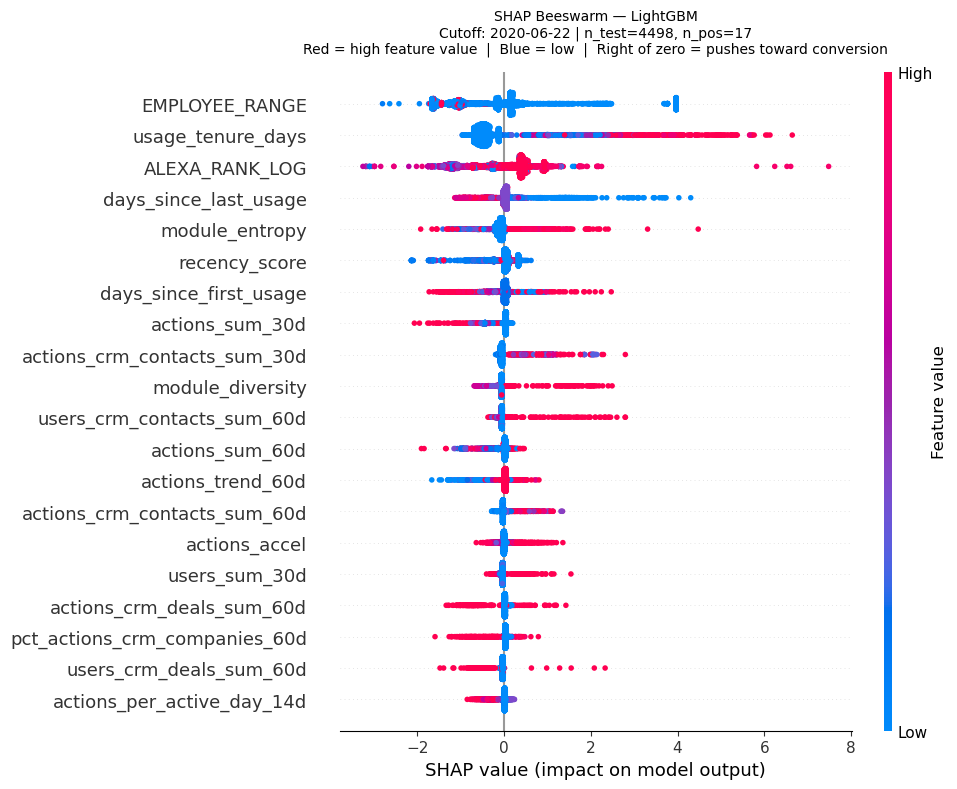


--- Plot 2/2: SHAP Waterfall — #1 Ranked Lead ---
  Company ID : 67
  Score      : 0.974
  Converted  : True



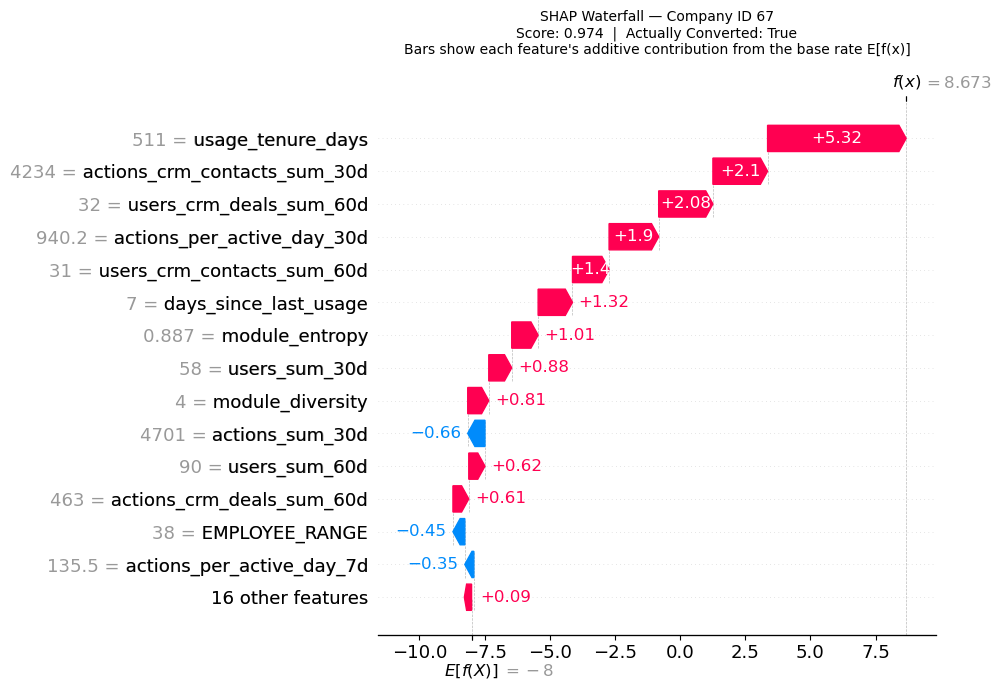


=== ENRICHED WEEKLY SALES CALL LIST — Top 10 ===
Production output: rank + propensity score + human-readable conversion driver.

 priority_rank  company_id  propensity_score  converted_actual                       top_feature_signal
             1          67          0.973876                 1 Long active usage tenure  (SHAP: +5.315)
             2         109          0.963300                 1 Long active usage tenure  (SHAP: +5.167)
             3         188          0.937776                 1 Long active usage tenure  (SHAP: +6.645)
             4         132          0.874536                 1 Long active usage tenure  (SHAP: +6.032)
             5        2813          0.735045                 0 Long active usage tenure  (SHAP: +5.720)
             6        3608          0.691539                 0 Long active usage tenure  (SHAP: +5.242)
             7        4436          0.680940                 0 Long active usage tenure  (SHAP: +5.038)
             8        5013          0.

In [19]:


def run_shap_analysis(backtester_obj, lead_table: pd.DataFrame):
    """
    Full SHAP analysis on the fold with the most test positives.

    Produces:
      1. Beeswarm summary plot  — global, which features matter and in which direction
      2. Waterfall plot         — local, why the #1 ranked lead scored so high
      3. Enriched sales list    — top_feature_signal string appended per lead

    Parameters
    ----------
    backtester_obj : PropensityBacktester
        Fitted backtester with metrics_results populated.
    lead_table : pd.DataFrame
        Output of run_backtest().

    Returns
    -------
    lead_table_enriched : pd.DataFrame
        Lead table with top_feature_signal column added.
    shap_df : pd.DataFrame
        Full SHAP value matrix (n_test_companies x n_selected_features).
    """

    # ── 1. Identify best fold ────────────────────────────────────────────────
    best_fold = max(backtester_obj.metrics_results, key=lambda f: f["n_test_pos"])
    cutoff_ts = pd.Timestamp(best_fold["cutoff"])
    print(f"Running SHAP on fold: {cutoff_ts.date()}  (n_pos={best_fold['n_test_pos']})")

    X_tr, y_tr, X_te, y_te = backtester_obj._build_fold_dataset(cutoff_ts)
    valid_cols = X_tr.columns[X_tr.notna().any()].tolist()
    X_tr_v = X_tr[valid_cols]
    X_te_v = X_te[valid_cols]

    # ── 2. Fit LightGBM pipeline ─────────────────────────────────────────────
    models    = backtester_obj._get_model_pipelines(total_input_features=len(valid_cols))
    lgbm_pipe = models["LightGBM"]
    lgbm_pipe.fit(X_tr_v, y_tr)

    # ── 3. Extract post-pipeline data ────────────────────────────────────────
    # SHAP must see data in the same feature space as the LightGBM leaves,
    # i.e. after imputation and RFE selection.
    imputer   = lgbm_pipe.named_steps["imputer"]
    rfe_step  = lgbm_pipe.named_steps["rfe"]
    lgbm_clf  = lgbm_pipe.named_steps["clf"]

    X_tr_rfe = rfe_step.transform(imputer.transform(X_tr_v))
    X_te_rfe = rfe_step.transform(imputer.transform(X_te_v))
    selected_features = list(X_te_rfe.columns)

    # ── 4. Build SHAP TreeExplainer ──────────────────────────────────────────
    # TreeExplainer is exact and fast for tree models — no sampling approximation.
    # We pass a small background sample so expected_value is computed correctly.
    explainer = shap.TreeExplainer(lgbm_clf)
    shap_output = explainer.shap_values(X_te_rfe, check_additivity=False)

    # Binary LightGBM returns [neg_class_shap, pos_class_shap]
    sv = shap_output[1] if isinstance(shap_output, list) else shap_output
    shap_df = pd.DataFrame(sv, columns=selected_features, index=X_te_rfe.index)

    # ── 5. Beeswarm Plot (Global) ────────────────────────────────────────────
    print("\n--- Plot 1/2: SHAP Beeswarm — Global Feature Impact ---")
    shap.summary_plot(
        sv,
        X_te_rfe,
        feature_names=selected_features,
        plot_type="dot",
        max_display=20,
        show=False,
        plot_size=None,
    )
    plt.gcf().set_size_inches(10, 8)
    plt.title(
        f"SHAP Beeswarm — LightGBM\n"
        f"Cutoff: {cutoff_ts.date()} | n_test={len(X_te_rfe)}, n_pos={best_fold['n_test_pos']}\n"
        f"Red = high feature value  |  Blue = low  |  Right of zero = pushes toward conversion",
        fontsize=10, pad=14
    )
    plt.tight_layout()
    plt.show()

    # ── 6. Waterfall Plot (Local — Top Lead) ─────────────────────────────────
    fold_leads = lead_table[lead_table["cutoff"] == cutoff_ts].sort_values("priority_rank")

    if not fold_leads.empty:
        top_id = fold_leads.iloc[0]["company_id"]
        if top_id in X_te_rfe.index:
            top_score  = fold_leads.iloc[0]["propensity_score"]
            top_actual = int(fold_leads.iloc[0]["converted_actual"])
            top_pos    = X_te_rfe.index.get_loc(top_id)

            base_val = (
                explainer.expected_value[1]
                if isinstance(explainer.expected_value, list)
                else explainer.expected_value
            )

            explanation = shap.Explanation(
                values        = sv[top_pos],
                base_values   = base_val,
                data          = X_te_rfe.iloc[top_pos].values,
                feature_names = selected_features
            )

            print(f"\n--- Plot 2/2: SHAP Waterfall — #1 Ranked Lead ---")
            print(f"  Company ID : {top_id}")
            print(f"  Score      : {top_score:.3f}")
            print(f"  Converted  : {bool(top_actual)}\n")

            shap.waterfall_plot(explanation, max_display=15, show=False)
            plt.gcf().set_size_inches(10, 7)
            plt.title(
                f"SHAP Waterfall — Company ID {top_id}\n"
                f"Score: {top_score:.3f}  |  Actually Converted: {bool(top_actual)}\n"
                f"Bars show each feature's additive contribution from the base rate E[f(x)]",
                fontsize=10, pad=14
            )
            plt.tight_layout()
            plt.show()

    # ── 7. Per-lead top_feature_signal strings ───────────────────────────────
    # Human-readable labels for known feature patterns
    STATIC_LABELS = {
        "module_entropy":         "Broad multi-module adoption",
        "ALEXA_RANK_LOG":         "Strong web presence (low Alexa rank)",
        "days_since_first_usage": "Long time on free tier",
        "usage_tenure_days":      "Long active usage tenure",
        "EMPLOYEE_RANGE":         "Company size signal",
        "recency_score":          "Recent platform activity",
        "module_diversity":       "Uses multiple CRM modules",
        "actions_accel":          "Accelerating usage growth",
        "days_since_last_usage":  "Recently active",
    }

    def _label(feat: str) -> str:
        if feat in STATIC_LABELS:
            return STATIC_LABELS[feat]
        for w in ["7d", "14d", "30d", "60d"]:
            module = (feat
                      .replace(f"_sum_{w}", "").replace(f"_trend_{w}", "")
                      .replace(f"active_days_{w}", "active")
                      .replace(f"actions_per_active_day_{w}", "intensity")
                      .replace("actions_crm_", "").replace("actions_", "")
                      .replace("users_crm_", "").replace("users_", "")
                      .upper())
            if f"_sum_{w}" in feat:
                kind = "user" if feat.startswith("users") else "action"
                return f"High {module} {kind}s ({w})"
            if f"_trend_{w}" in feat:
                return f"Accelerating {module} trend ({w})"
            if f"active_days_{w}" in feat:
                return f"Frequent logins ({w})"
            if f"actions_per_active_day_{w}" in feat:
                return f"High session intensity ({w})"
        return feat.replace("_", " ").title()

    def _top_signal(shap_row: pd.Series) -> str:
        pos = shap_row[shap_row > 0]
        if pos.empty:
            return "No strong positive signal"
        top_feat = pos.idxmax()
        return f"{_label(top_feat)}  (SHAP: {pos[top_feat]:+.3f})"

    signal_map = {cid: _top_signal(shap_df.loc[cid]) for cid in shap_df.index}

    # ── 8. Enrich lead table ─────────────────────────────────────────────────
    lead_out  = lead_table.copy()
    fold_mask = lead_out["cutoff"] == cutoff_ts
    lead_out.loc[fold_mask, "top_feature_signal"] = (
        lead_out.loc[fold_mask, "company_id"].map(signal_map)
    )

    # ── 9. Print production-ready sales list ────────────────────────────────
    print("\n=== ENRICHED WEEKLY SALES CALL LIST — Top 10 ===")
    print("Production output: rank + propensity score + human-readable conversion driver.\n")
    pd.set_option("display.max_colwidth", 55)
    top10 = (
        lead_out[fold_mask]
        .head(10)
        [["priority_rank", "company_id", "propensity_score", "converted_actual", "top_feature_signal"]]
    )
    print(top10.to_string(index=False))

    return lead_out, shap_df


# ── Execute ──────────────────────────────────────────────────────────────────
lead_table_with_signals, shap_values_df = run_shap_analysis(
    backtester,
    lead_priority_table,
)

# Production Deployment Plan

The problem requires generating a **weekly prioritized list every Sunday**. Below is how this model would transition from backtest to production.

---

## 1. Retraining Strategy

**Expanding window retraining (recommended for this dataset size):**
- Each Sunday, retrain the model using **all historical data available** up to Saturday (the cutoff).
- Label positives as: companies that converted at any point in the past.
- Label the test set (this week's scoring) as all current free-tier portals.
- This is the safest approach given the small dataset (~200 customers). A rolling window would reduce training size further.

**Retraining frequency:** Weekly, triggered on Sunday mornings via a scheduled job (cron / Airflow / dbt).

---

## 2. Pipeline Steps (Sunday Job)

```
1. Pull usage_actions WHERE WHEN_TIMESTAMP >= (today - 90 days)  ← rolling usage window
2. Pull current noncustomers (free-tier portals with no CLOSEDATE)
3. Pull all historical customers (for training labels)
4. Run VectorizedUsageFeatureBacktester.build() at cutoff = Sunday
5. Encode company static features (INDUSTRY, EMPLOYEE_RANGE, ALEXA_RANK)
6. Fit PropensityBacktester on all available training data
7. Score all active non-customers
8. Output top-K prioritized list → CRM / Salesforce / HubSpot Deals
```

---

## 3. Cold-Start Problem

New portals (< 7 days of usage) have no meaningful rolling features. Options:
- **Exclude** from scoring until they have ≥ 14 days of usage data.
- **Fallback to static features only** (company size, industry, Alexa rank) with a lower-confidence score.
- Flag as `cold_start=True` in the output list so reps know the score is less reliable.

---

## 4. Feedback Loop

Model performance degrades without ground truth feedback:
- **Log every scored company and its rank** at each Sunday cutoff.
- **30 days later**, join back to the customer table to check if they converted.
- Use this to compute real P@K weekly and alert if performance degrades >20% from backtest baseline.
- **Sales rep feedback** (e.g., 'this lead was unqualified') can be used as additional negative labels.

---

## 5. Model Monitoring

Key signals to monitor in production:
- **Propensity score distribution shift** — if the average score drifts significantly, features may have changed.
- **Feature drift** — monitor mean/std of top features (e.g., `actions_sum_30d`) week-over-week.
- **Conversion rate stability** — if the actual weekly conversion rate drops significantly, the model needs retraining with a recency bias.

---

## 6. Output Format for Sales Team

The final weekly output table should contain:

| company_id | company_name | propensity_score | priority_rank | employee_range | industry | days_since_last_usage | top_feature_signal |
|---|---|---|---|---|---|---|---|
| 4521 | Acme Corp | 0.82 | 1 | 26-50 | TECH | 2 | High Deals usage (30d) |

The `top_feature_signal` column (a human-readable explanation of the top driver) can be derived from LightGBM SHAP values and makes the list directly actionable for reps without requiring ML knowledge.